# Chromatin PTR analysis
February 32, 2024

Update PTR analysis of latest chromatin deconvolution results. Higher resolution chromatin results. Goal is to summarize a gene's cycling chromatin with a top k values of cycling chromatin.

Possibly sweep for what k values can be reasonable. Maybe think through how we can sweep for an appropriate k.

In [2]:
# Preamble, notebook setup and imports

%load_ext autoreload
%autoreload 2
%matplotlib inline
%config InlineBackend.figure_format = 'retina'

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [3]:
import glob

outdir = 'output/deconvolve_rep1_g006_2024_02_20/chromatin/'

from cc_src.peak_to_trough_anaysis import PeakToTroughAnalysis

peak_to_trough_analysis = PeakToTroughAnalysis(outdir)


In [13]:
peak_to_trough_analysis.load_ptr_files()
peak_to_trough_analysis.sort_gene_ptrs()
peak_to_trough_analysis.compute_gene_ptr_rank_per_k()

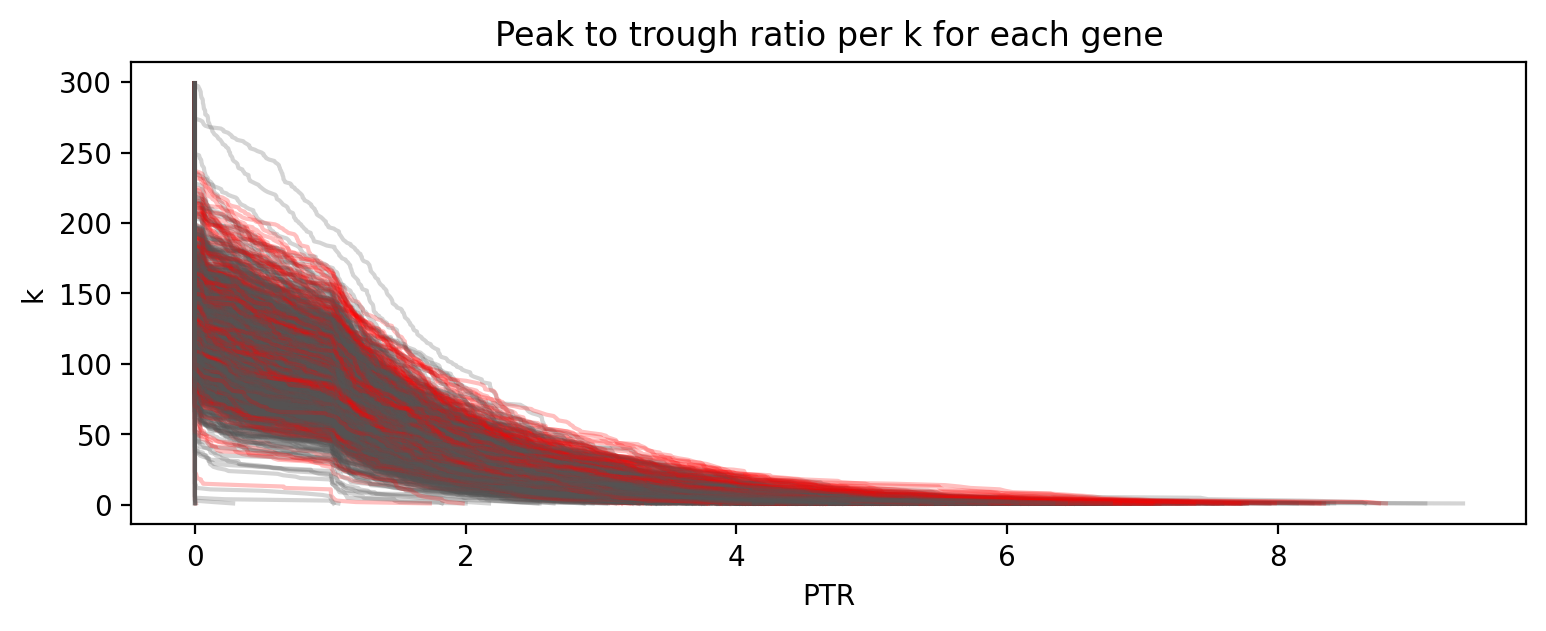

In [24]:
peak_to_trough_analysis.plot_ptr_k_gene()

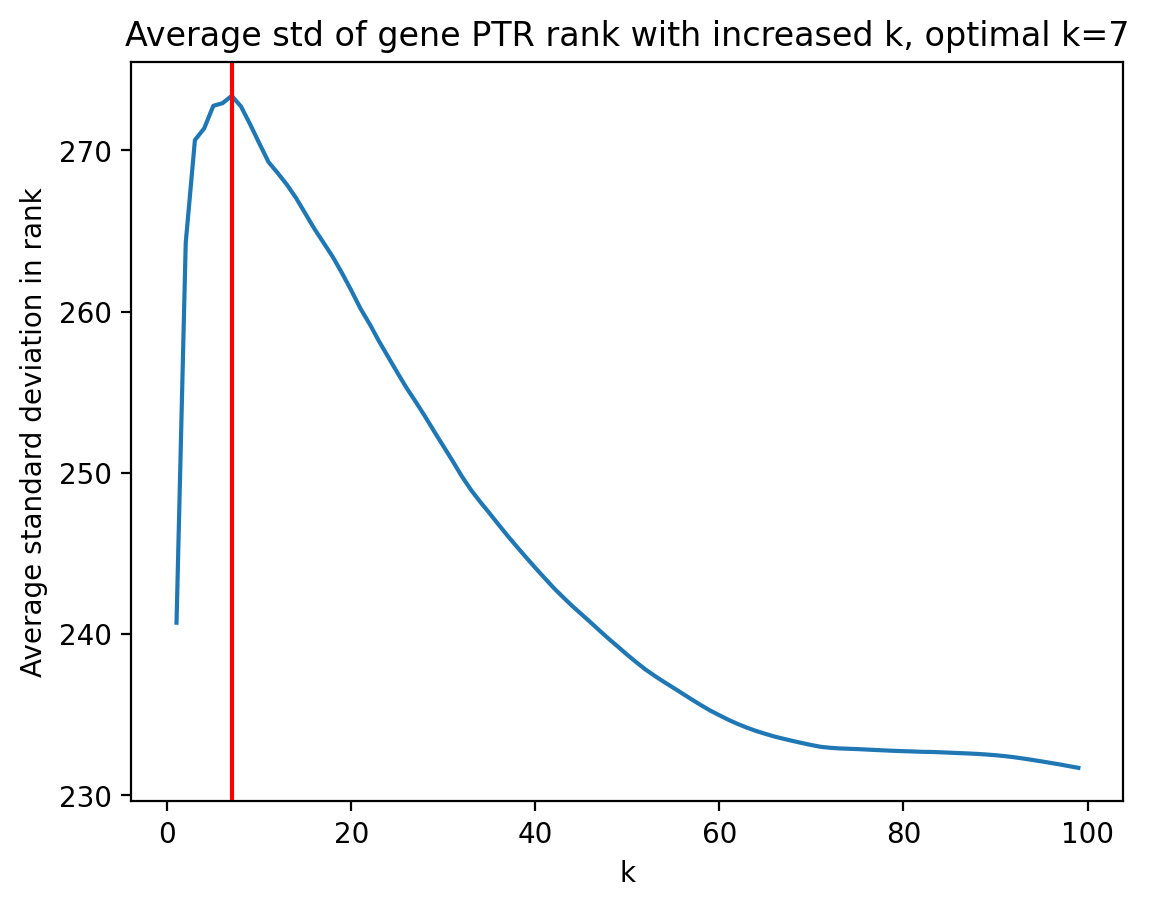

In [51]:
peak_to_trough_analysis.compute_optimal_k()

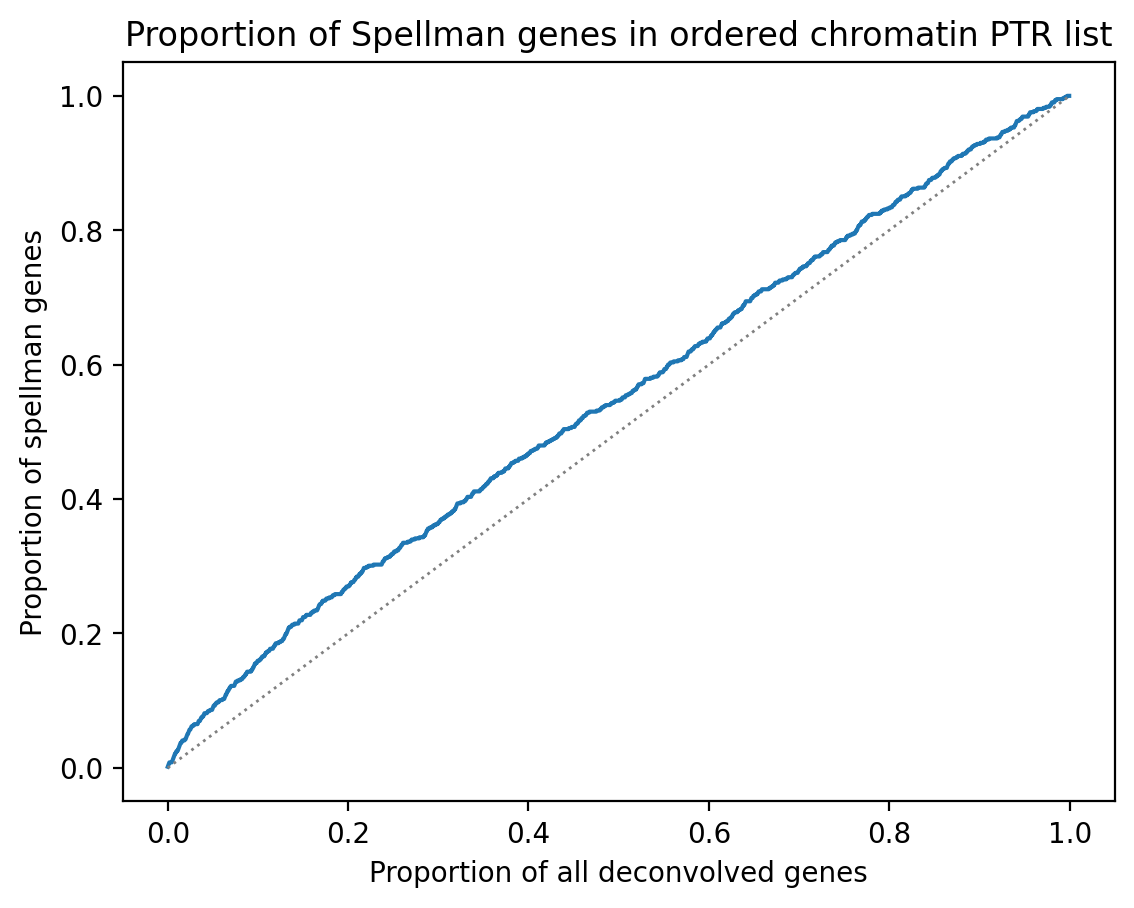

In [54]:
peak_to_trough_analysis.spellman_analysis()

Text(0.5, 1.0, 'Gene PTR values for k=7\nn=2239, q05=2.7, q95=4.5')

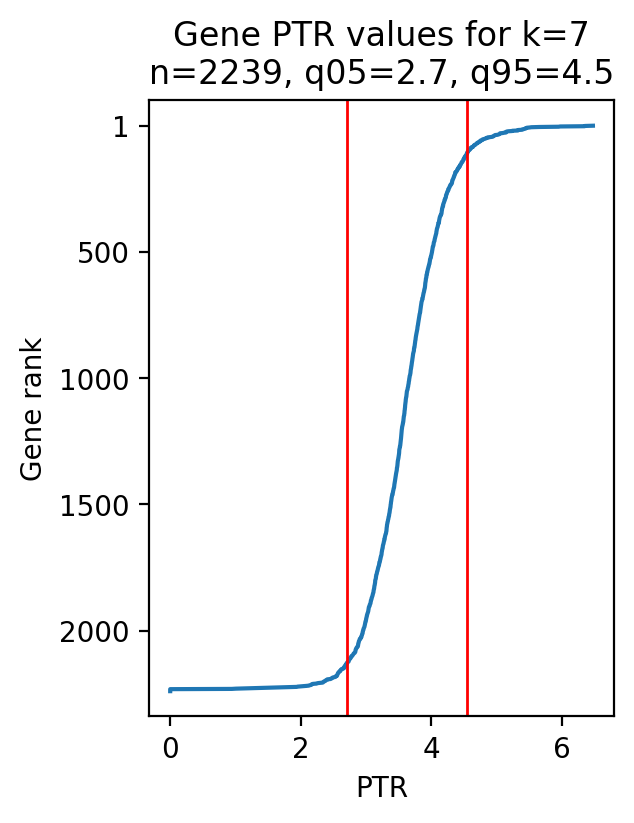

In [82]:
plt_data = peak_to_trough_analysis.k_sorted_genes
n = len(plt_data)

plt.figure(figsize=(3, 4))
plt.plot(plt_data['ptr'], plt_data['rank']+1)
plt.xlabel("PTR")
plt.ylabel("Gene rank")
plt.yticks([1] + list(np.arange(500, n, 500)))
plt.ylim(n+100, 1-100)

ptr_values = plt_data['ptr']
q05, q95 = np.quantile(ptr_values, q=[0.05, 0.95])

plt.axvline(q05, c='red', lw=1)
plt.axvline(q95, c='red', lw=1)

plt.title(f"Gene PTR values for k={peak_to_trough_analysis.optimal_k}\n" +
         f"n={n}, q05={q05:0.1f}, q95={q95:.1f}")


In [55]:
peak_to_trough_analysis.k_sorted_genes.head(10)

,rank,gene,spellman,ptr
orf_name,,,,
YMR001C,0,CDC5,True,6.47687
YOR058C,1,ASE1,True,6.351216
YPL141C,2,FRK1,True,6.34839
YNL145W,3,MFA2,True,5.974155
YPR159W,4,KRE6,True,5.951757
YLR327C,5,TMA10,False,5.658587
YMR274C,6,RCE1,False,5.532524
YDR253C,7,MET32,False,5.507582
YLL042C,8,ATG10,False,5.465655


In [56]:
peak_to_trough_analysis.k_sorted_genes.tail(10)

,rank,gene,spellman,ptr
orf_name,,,,
YOR391C,2229,HSP33,False,0.943902
YLR461W,2230,PAU4,False,0.000087
YKR105C,2231,VBA5,False,0.000015
YPL280W,2232,HSP32,False,0.000013
YFL060C,2233,SNO3,True,0.000012
YLL064C,2234,PAU18,False,0.00001
YNL335W,2235,DDI3,False,0.00001
YNL336W,2236,COS1,False,0.00001
YLR466W,2237,YRF1-4,False,0.00001
